In [1]:
%load_ext autoreload
%autoreload 2

import os
# import cospar
import scanpy as sc
import PINN 
import numpy as np
import pandas as pd

import palantir
from PINN import tl

import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("../../")

In [2]:
import anndata as ad
from tqdm.contrib.concurrent import process_map

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
subset_up = sc.read_h5ad("data/klein_subset.h5ad")

In [4]:
subset_up

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [7]:
subset_up.uns['pop']['mean'] = np.array([30000, 150000, 450000])

In [8]:
var1 = np.var([6000*4,6000*5, 6000*6])
var2 = np.var([30000*4,30000*5, 30000*6])
var3 = np.var([150000*2,150000*3, 150000*4])
subset_up.uns['pop']['var'] = np.array([var1, var2, var3])

In [9]:
subset_up.uns['pop']

{'mean': array([ 30000, 150000, 450000]),
 'n_lib': array([3, 3, 3]),
 't': array([2, 4, 6]),
 'var': array([2.4e+07, 6.0e+08, 1.5e+10])}

In [10]:
subset_up.write_h5ad("data/klein_subset.h5ad")

In [39]:
# create new adata with DM coordinate as X
new_ad = ad.AnnData(
    X = subset_up.obsm['DM_EigenVectors_multiscaled'],
    obs = subset_up.obs.copy(),
    var = pd.DataFrame(['DM_%d'%d for d in range(5)]).set_index(0)
)

new_ad.obsp['connectivities'] = subset_up.obsp['connectivities'].copy()
new_ad.obsp['distances'] = subset_up.obsp['distances'].copy()
new_ad.layers['DM'] = new_ad.X.copy()
new_ad.obsm["X_pca"] = subset_up.obsm["X_pca"]
new_ad.obsm["X_umap"] = subset_up.obsm["X_umap"]

# construct cluster specific adata

In [14]:
cluster, cells = np.unique(subset_up.obs['Meta clones'], return_counts=True)
Meta_clone_cb = {c:subset_up.obs.query("`Meta clones` == @c").index for c in cluster}

In [16]:
cluster[np.where(cells > 3000)[0]]

array(['-1.0', '0', '1', '2', '3', '4'], dtype=object)

In [69]:
for clone_id in ['0', '1', '2', '3', '4']:

    clone_ad = subset_up[Meta_clone_cb[clone_id]].copy()
    sc.pp.neighbors(clone_ad, n_neighbors=15)

    # sampling by parrelleling
    def iter_fn(i):
        return tl.sample_deltax(clone_ad, xkey = 'DM_EigenVectors_multiscaled', progressbar=False)
    tuples = process_map(iter_fn, np.arange(60), max_workers=30)

    # stack and save
    delta_DM = np.stack([t[0] for t in tuples])
    neighbor_ls = np.stack([t[1] for t in tuples])
    np.save(f"data/Weinreb_clone/clone{clone_id}_deltaDM.npy", delta_DM)
    np.save(f"data/Weinreb_clone/clone{clone_id}_neighbors.npy", neighbor_ls)

    clone_ad.obsm['Delta_DM_clone'] = np.mean(delta_DM, axis=0)

    # count cells
    all_cellcount = subset_up.obs['timepoint_tx_days'].astype(int).value_counts().to_dict()
    clone_cellcount = clone_ad.obs['timepoint_tx_days'].astype(int).value_counts().to_dict()

    # subset the population size
    for i, t in enumerate(subset_up.uns['pop']['t']):
        prop = clone_cellcount[t]/all_cellcount[t]
        
        clone_ad.uns['pop']['mean'][i] = subset_up.uns['pop']['mean'][i] * prop
        clone_ad.uns['pop']['var'][i] = subset_up.uns['pop']['var'][i] * prop**2

    # then save
    h5_path = f"data/Weinreb_clone/clone{clone_id}.h5ad"
    clone_ad.write_h5ad(h5_path)
    print(f"adata for clone {clone_id} save to {h5_path}")

100%|██████████| 60/60 [00:39<00:00,  1.51it/s]


adata for clone 0 save to data/Weinreb_clone/clone0.h5ad


100%|██████████| 60/60 [00:21<00:00,  2.79it/s]


adata for clone 1 save to data/Weinreb_clone/clone1.h5ad


100%|██████████| 60/60 [00:24<00:00,  2.44it/s]


adata for clone 2 save to data/Weinreb_clone/clone2.h5ad


100%|██████████| 60/60 [00:19<00:00,  3.08it/s]


adata for clone 3 save to data/Weinreb_clone/clone3.h5ad


100%|██████████| 60/60 [00:08<00:00,  7.14it/s]


adata for clone 4 save to data/Weinreb_clone/clone4.h5ad


In [9]:
for clone_id in ['0', '1', '2', '3', '4']:

     # then save
    h5_path = f"data/Weinreb_clone{clone_id}.h5ad"
    clone_ad = sc.read_h5ad(h5_path)

    print(clone_ad.uns['pop']['mean'] / clone_ad.uns['pop']['mean'][0])

[ 1.         11.63432447 58.63015128]
[ 1.          8.71381759 42.16002185]
[ 1.         10.58604156 41.97815663]
[ 1.          8.24733412 14.41646919]
[ 1.          7.71695761 23.33042394]


In [ ]:
# stack and save
delta_DM = np.stack([t[0] for t in tuples])
neighbor_ls = np.stack([t[1] for t in tuples])
np.save(f"data/Weinreb_clone_{clone_id}_deltaDM.npy", delta_DM)
np.save(f"data/Weinreb_clone_{clone_id}_neighbors.npy", neighbor_ls)

clone_ad.obsm['Delta_DM_clone'] = np.mean(delta_DM, axis=0)

In [ ]:
all_cellcount = subset_up.obs['timepoint_tx_days'].astype(int).value_counts().to_dict()
clone_cellcount = clone_ad.obs['timepoint_tx_days'].astype(int).value_counts().to_dict()

# subset the population size
for i, t in enumerate(subset_up.uns['pop']['t']):
    prop = clone_cellcount[t]/all_cellcount[t]
    
    clone_ad.uns['pop']['mean'][i] = subset_up.uns['pop']['mean'][i] * prop
    clone_ad.uns['pop']['var'][i] = subset_up.uns['pop']['var'][i] * prop**2

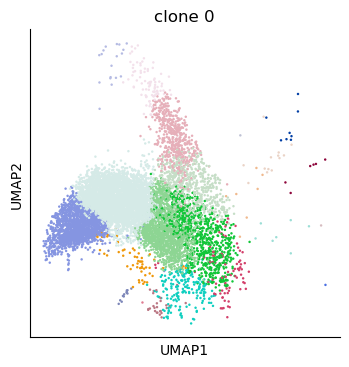

In [35]:
sc.pl.umap(subset_up[Meta_clone_cb['0']], color='label_man', title='clone 0', legend_loc='none')

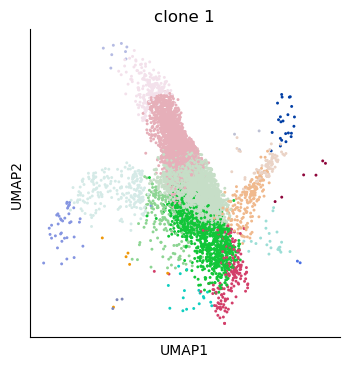

In [36]:
sc.pl.umap(subset_up[Meta_clone_cb['1']], color='label_man', title='clone 1', legend_loc='none')

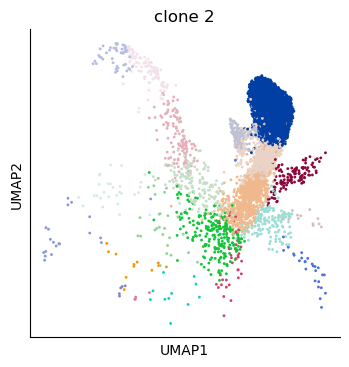

In [33]:
sc.pl.umap(subset_up[Meta_clone_cb['2']], color='label_man', legend_loc='none', title='clone 2')

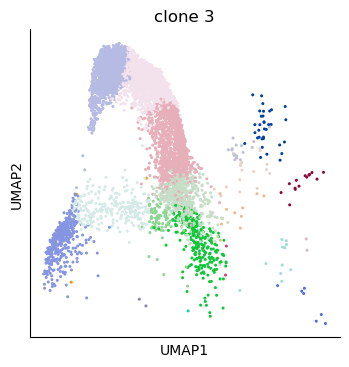

In [31]:
sc.pl.umap(subset_up[Meta_clone_cb['3']], color='label_man', legend_loc='none', title='clone 3')

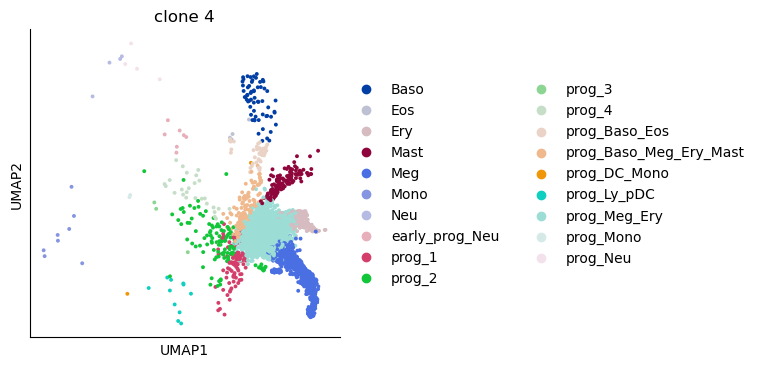

In [30]:
sc.pl.umap(subset_up[Meta_clone_cb['4']], color='label_man', title='clone 4')